# BEE2041 Empirical Project: What property and location factors determine Airbnb listing prices in London?
## 04_modelling

In [29]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [31]:
# Load cleaned data
df = pd.read_csv("../data/cleaned/london_clean.csv")

df.head()
df.shape

(46390, 21)

In [33]:
# Start train and test split model
# Define X and y
X = df.drop(["price", "log_price"], axis=1)
y = df["log_price"]

# 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
# Create a baseline linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

y_predict_lr = lr.predict(X_test)

# Evaluate model
print("Linear Regression R Squared:", r2_score(y_test, y_predict_lr))
print("Linear Regression Root Mean Squared Error:", root_mean_squared_error(y_test, y_predict_lr))

Linear Regression R Squared: 0.621476844055324
Linear Regression Root Mean Squared Error: 0.4411200775986225


In [37]:
# Create Random Forest Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_predict_rf = rf.predict(X_test)

# Evaluate model
print("Random Forest R Squared:", r2_score(y_test, y_predict_rf))
print("Random Forest Root Mean Squared Error:", root_mean_squared_error(y_test, y_predict_rf))

Random Forest R Squared: 0.7968027082032036
Random Forest Root Mean Squared Error: 0.3231986638504583


In [38]:
# Compare the R Squared of both models
print("Linear Regression R Squared:", r2_score(y_test, y_predict_lr))
print("Random Forest R Squared:", r2_score(y_test, y_predict_rf))

Linear Regression R Squared: 0.621476844055324
Random Forest R Squared: 0.7968027082032036


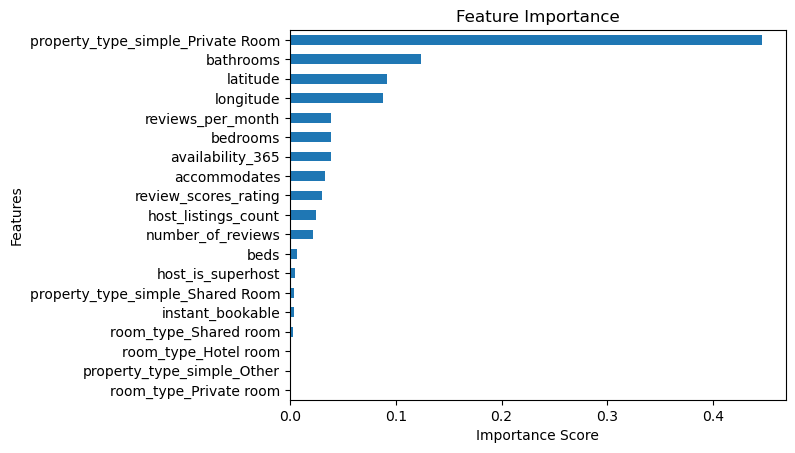

In [49]:
# Create a feature importance series from the random forest model
importance = pd.Series(rf.feature_importances_, index=X.columns)

# Sort values by importance
importance = importance.sort_values()

# Plot feature importance series
importance.plot(kind="barh")

# Label axes
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

# Save figure
plt.savefig("../figures/04_feature_importance.png", bbox_inches='tight')

# Show plot
plt.show()

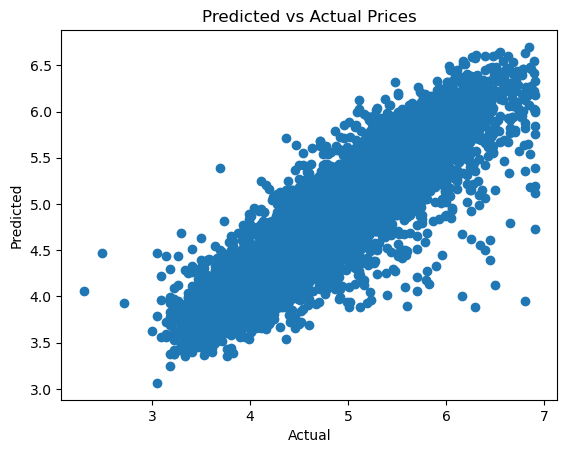

In [47]:
# Compare predicted vs actual prices
# Create a scatter plot of test values and predicted values
plt.scatter(y_test, y_predict_rf)

# Label axes
plt.title("Predicted vs Actual Prices")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# Save figure
plt.savefig("../figures/04_predicted_vs_actual_prices.png")

# Show plot
plt.show()